In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
raw_data = pd.read_csv("./used_car_train_20200313.csv",sep = '\s+')
raw_data.info()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\33529\AppData\Local\Temp\ipykernel_4200\3771866115.py:1: SyntaxWarning: invalid escape sequence '\s'
  raw_data = pd.read_csv("./used_car_train_20200313.csv",sep = '\s+')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              150000 non-null  float64
 4   brand              150000 non-null  float64
 5   bodyType           150000 non-null  float64
 6   fuelType           150000 non-null  float64
 7   gearbox            150000 non-null  object 
 8   power              150000 non-null  object 
 9   kilometer          150000 non-null  object 
 10  notRepairedDamage  150000 non-null  object 
 11  regionCode         150000 non-null  int64  
 12  seller             150000 non-null  int64  
 13  offerType          150000 non-null  float64
 14  creatDate          150000 non-null  float64
 15  price              150000 non-null  float64
 16  v_

c:\Users\33529\anaconda3\envs\myproject\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\33529\anaconda3\envs\myproject\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


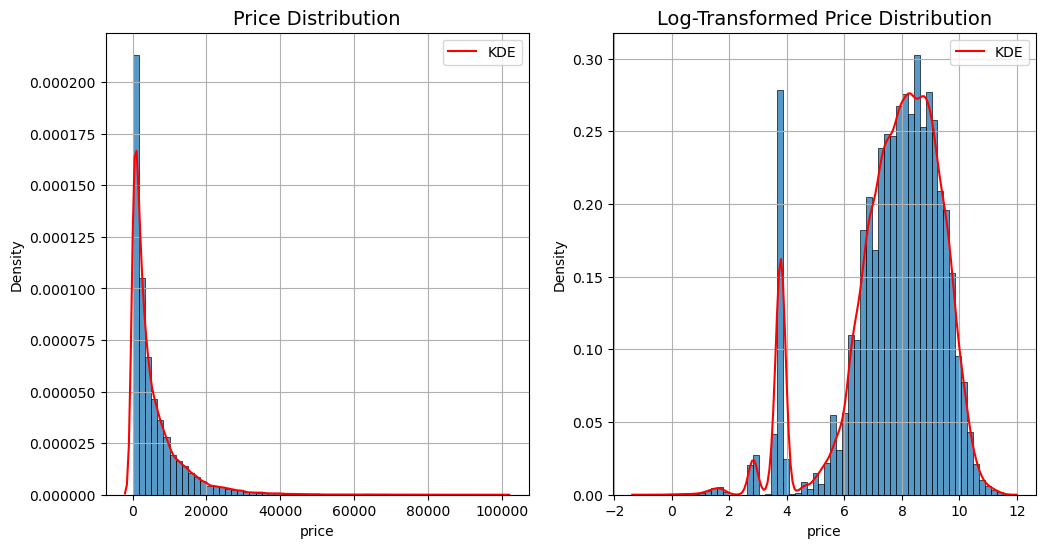

In [4]:
# 构建car_age特征，只保留年份信息
data = raw_data.copy()
data['car_age'] = 2026 - data['regDate'] // 10000

plt.figure(figsize=(12, 6))
# 原始价格分布
plt.subplot(1, 2, 1)

sns.histplot(data['price'], bins = 60, stat = 'density')
sns.kdeplot(data['price'], color='red', label = 'KDE')
plt.title("Price Distribution", fontsize=14)
plt.grid(True)
plt.legend()

# 价格分布（对数变换）
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(data['price']), bins = 60, stat = 'density')
sns.kdeplot(np.log1p(data['price']), color='red', label = 'KDE')
plt.title("Log-Transformed Price Distribution", fontsize=14)
plt.grid(True)
plt.legend()

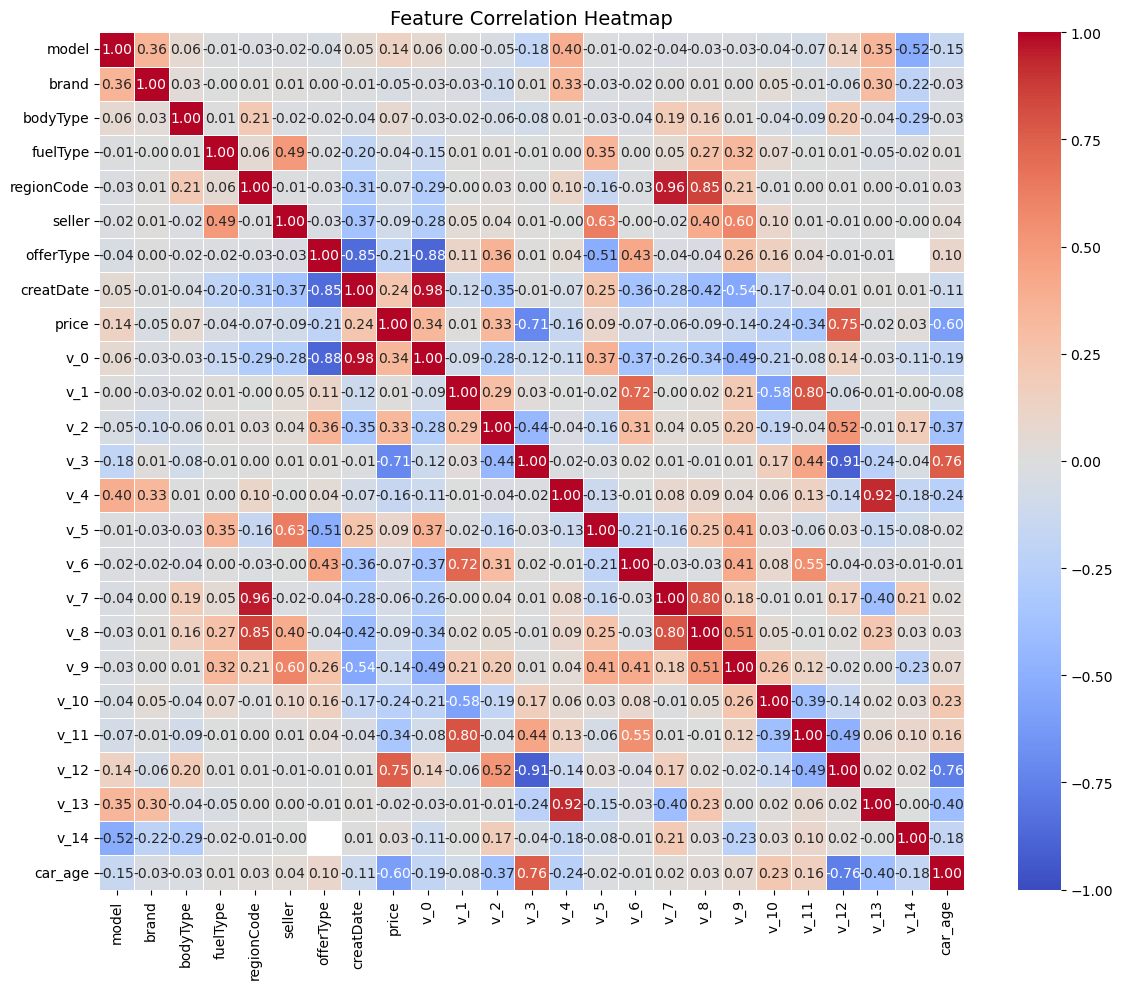

In [5]:
numeric_data = data.select_dtypes(include=[np.number])  
drop_cols = ['SaleID', 'regDate', 'name']
numeric_data = numeric_data.drop(columns=drop_cols, errors='ignore')
# numeric_data['price'] = np.log1p(numeric_data['price'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(12, 10))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
data_for_pca = numeric_data.drop(['price'], axis = 1) 
 # 填充缺失值

X_PCA = pca.fit_transform(data_for_pca.fillna(0))

In [20]:
print(X_PCA.shape)
print(pca.components_)
# print(pca.explained_variance_ratio_)

(150000, 2)
[[ 3.25270189e-07 -7.72147065e-09 -1.13261064e-08 -2.54657445e-07
  -4.80791787e-02 -7.17130314e-02 -6.42030846e-01  7.61801829e-01
   1.68708966e-06 -6.18504139e-08 -5.00227403e-08 -3.19771620e-09
  -9.35655906e-09  5.56904697e-09 -7.08695461e-09 -2.00936180e-08
  -5.88289094e-08 -1.17897774e-07 -8.58723922e-08 -9.81530493e-09
   3.32280846e-09  1.48266165e-09  3.19607465e-10 -7.70381650e-08]
 [-2.75953035e-07  2.95000492e-08  1.43899460e-07  2.30727908e-06
   3.00888998e-01  6.59027085e-01 -5.64881225e-01 -3.95042166e-01
  -4.56264404e-07  6.01888499e-09 -1.99200068e-08  3.43769948e-09
   1.31245128e-08  2.32468615e-08 -6.21975913e-09  1.33896541e-07
   4.31931064e-07  3.37044800e-07  4.14103992e-08 -2.15533658e-09
  -2.20133196e-09 -2.86658277e-11 -1.66179761e-10  3.76671796e-08]]


In [15]:
help(pd.DataFrame.drop)

Help on function drop in module pandas.core.frame:

drop(
    self,
    labels: 'IndexLabel | None' = None,
    *,
    axis: 'Axis' = 0,
    index: 'IndexLabel | None' = None,
    columns: 'IndexLabel | None' = None,
    level: 'Level | None' = None,
    inplace: 'bool' = False,
    errors: 'IgnoreRaise' = 'raise'
) -> 'DataFrame | None'
    Drop specified labels from rows or columns.

    Remove rows or columns by specifying label names and corresponding
    axis, or by directly specifying index or column names. When using a
    multi-index, labels on different levels can be removed by specifying
    the level. See the :ref:`user guide <advanced.shown_levels>`
    for more information about the now unused levels.

    Parameters
    ----------
    labels : single label or list-like
        Index or column labels to drop. A tuple will be used as a single
        label and not treated as a list-like.
    axis : {0 or 'index', 1 or 'columns'}, default 0
        Whether to drop labels fro